# What is your counterparty's promise to pay worth?
### Live demo · CVA, DVA and machine learning on the TIIE de Fondeo curve

### Maurilio Patiño García
**Universidad Anáhuac · Master's in Risk**

We are going to build, from scratch and live, the whole chain: simulate the Mexican curve, measure
exposure, price counterparty risk, look at its mirror image (DVA), combine the two in the bilateral
adjustment, and finally train a much faster surrogate of the engine, especially when pricing in batch.

> **Simplifications for the demo:** a flat curve, quarterly payments, expected exposure discounted with the
> market curve, and assumed spreads. The figures are **illustrative**: they show orders of magnitude, not
> final thesis results. Exposure is evaluated on the payment dates, where the floating-leg formula is
> exact (no accrued coupon is left out). This does not remove the time-integration error of the
> quarterly grid.

In [1]:
import numpy as np, time
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (11, 4.2), 'axes.grid': True, 'grid.alpha': .25})

# --- G2++ calibrated in the thesis to ATM swaptions (Bloomberg SWPM, 24-Mar-2026) ---
a, b   = 0.148849, 0.982642      # mean reversion: slow factor (≈ level) / fast (≈ slope)
sigma, eta = 0.026973, 0.062209  # volatilities
rho    = -0.913918               # correlation between factors
f0, R  = 0.0710, 0.25            # flat curve level (assumption) | recovery (EM CDS convention)
Noc    = 10_000_000              # notional: 10 MM MXN
T, delta = 5.0, 0.25             # 5Y payer swap, quarterly payments

pay = np.arange(delta, T + 1e-9, delta)   # payment dates
mon = pay[:-1]                            # monitoring dates = payment dates (no accrued coupon omitted)
M, dt = len(pay), delta
print(f"{T:.0f}Y payer swap · notional {Noc:,} MXN · {M} quarterly payments")

5Y payer swap · notional 10,000,000 MXN · 20 quarterly payments


---
## 1 · Simulating the future
$r(t) = x(t) + y(t) + \varphi(t)$: two correlated Gaussian factors. Each factor is simulated **exactly** (no
discretisation error). The correlation between innovations is approximated by $\rho$; with quarterly
steps the exact correlation is $0.998\,\rho$, a negligible effect. The relevant error is the Monte Carlo one.

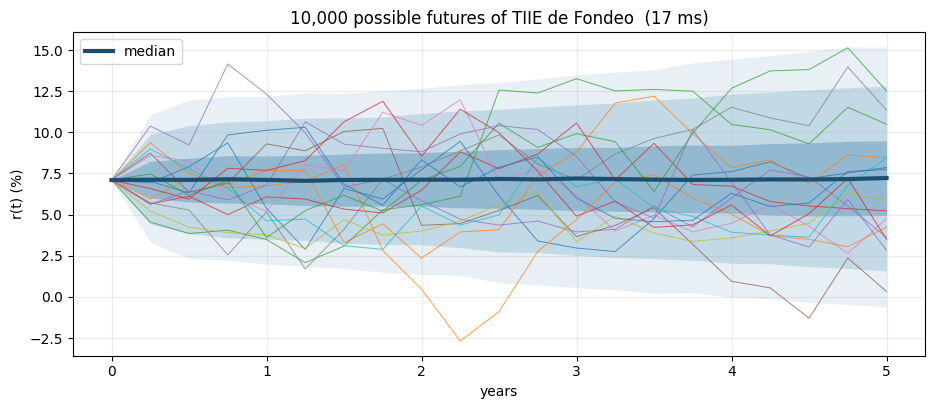

In [2]:
def phi(t):
    """G2++ φ(t): market instantaneous forward (flat curve f0) plus the convexity adjustment
    that makes the model reproduce the initial curve (Brigo and Mercurio, 2006)."""
    ea, eb = 1 - np.exp(-a*t), 1 - np.exp(-b*t)
    return (f0 + sigma**2/(2*a**2)*ea**2 + eta**2/(2*b**2)*eb**2
               + rho*sigma*eta/(a*b)*ea*eb)

def simulate(N=10_000, seed=42):
    rng = np.random.default_rng(seed)
    x = np.zeros((N, M+1)); y = np.zeros((N, M+1))
    sx = sigma*np.sqrt((1-np.exp(-2*a*dt))/(2*a))
    sy = eta  *np.sqrt((1-np.exp(-2*b*dt))/(2*b))
    for i in range(M):
        z1 = rng.standard_normal(N)
        z2 = rho*z1 + np.sqrt(1-rho**2)*rng.standard_normal(N)
        x[:, i+1] = x[:, i]*np.exp(-a*dt) + sx*z1
        y[:, i+1] = y[:, i]*np.exp(-b*dt) + sy*z2
    return x, y

t0 = time.perf_counter(); x, y = simulate(); t_sim = time.perf_counter() - t0
tt = np.concatenate([[0.0], pay])
r = x + y + phi(tt)                      # short rate r = x + y + φ(t)

fig, ax = plt.subplots()
for q, al in [(1, .10), (5, .18), (25, .30)]:
    ax.fill_between(tt, np.percentile(100*r, q, axis=0), np.percentile(100*r, 100-q, axis=0),
                    color='#2471a3', alpha=al, lw=0)
ax.plot(tt, 100*r[:15].T, lw=.7, alpha=.75)
ax.plot(tt, np.median(100*r, axis=0), color='#1b4f72', lw=3, label='median')
ax.set(xlabel='years', ylabel='r(t) (%)', title=f'10,000 possible futures of TIIE de Fondeo  ({t_sim*1000:.0f} ms)')
ax.legend(); plt.show()

> **Reading.** The fan widens with the square root of time: at five years the 90% band spans
> about eleven percentage points. This is **not** a rate forecast: it is the uncertainty the market is
> pricing today, under the measure $\mathbb{Q}$. The individual paths show the combination of the two
> factors: fast variations over a slowly changing level.
>
> These paths are simulated **once**.
> Exposure, CVA, DVA, the scenarios and the model training are all computed by reusing
> this same cube. *Simulate once, price everything.*

---
## 2 · Pricing the swap in every future
Closed-form zero-coupon bond formula for the G2++. This produces the **MtM cube**: one value per
path, per date.

In [3]:
def B(k, tau): return (1 - np.exp(-k*tau)) / k

def Vv(tau):                       # G2++ integrated variance (Brigo-Mercurio)
    tau = np.maximum(tau, 0)
    return ((sigma**2/a**2)*(tau + (2/a)*np.exp(-a*tau) - (1/(2*a))*np.exp(-2*a*tau) - 3/(2*a))
          + (eta**2 /b**2)*(tau + (2/b)*np.exp(-b*tau) - (1/(2*b))*np.exp(-2*b*tau) - 3/(2*b))
          + 2*rho*(sigma*eta/(a*b))*(tau + (np.exp(-a*tau)-1)/a + (np.exp(-b*tau)-1)/b
                                         - (np.exp(-(a+b)*tau)-1)/(a+b)))

def P(ti, Tj, xi, yi):             # P(t,T) with convexity correction
    tau = Tj - ti
    return np.exp(-f0*tau + 0.5*(Vv(tau) - Vv(Tj) + Vv(ti)) - B(a,tau)*xi - B(b,tau)*yi)

P0    = np.array([P(0, Tj, 0, 0) for Tj in pay])
K_atm = (1 - P0[-1]) / (delta * P0.sum())          # ATM fixed rate
DF    = np.exp(-f0 * mon)

t0 = time.perf_counter()
Pn_l, ann_l = [], []
for j, ti in enumerate(mon, start=1):
    rem = pay[pay > ti + 1e-9]
    Pm  = np.stack([P(ti, Tj, x[:, j], y[:, j]) for Tj in rem], axis=1)
    Pn_l.append(Pm[:, -1]); ann_l.append(delta * Pm.sum(axis=1))
t_val = time.perf_counter() - t0

V   = [Noc*((1 - Pn) - K_atm*an) for Pn, an in zip(Pn_l, ann_l)]   # MtM by date
EE  = np.array([np.maximum( v, 0).mean() for v in V])              # expected exposure
ENE = np.array([np.maximum(-v, 0).mean() for v in V])              # expected negative exposure
PFE = np.array([np.percentile(np.maximum(v, 0), 97.5) for v in V])
print(f"ATM fixed rate: {K_atm:.4%}   |   MtM cube priced in {t_val*1000:.0f} ms")

ATM fixed rate: 7.1634%   |   MtM cube priced in 33 ms


> **Reading.** The ATM fixed rate comes out at **7.16%**, slightly above the level of the curve
> (7.10%, continuously compounded): it is the conversion to quarterly payments. At $t=0$ prices do
> not depend on the G2++ parameters. At that rate the swap is worth zero today; afterwards, its value changes with rates.
>
> Pricing 10,000 paths × 19 dates × all cash flows takes **tens of milliseconds**. Hold on to that
> order of magnitude: on a book, it gets multiplied by hundreds of trades and by dozens of bumps.

### One distribution, split at zero
At the exposure peak, we look at the value of the swap across the 10,000 paths. **The right half feeds
the CVA; the left half feeds the DVA.** It is the same simulation read from
both sides.

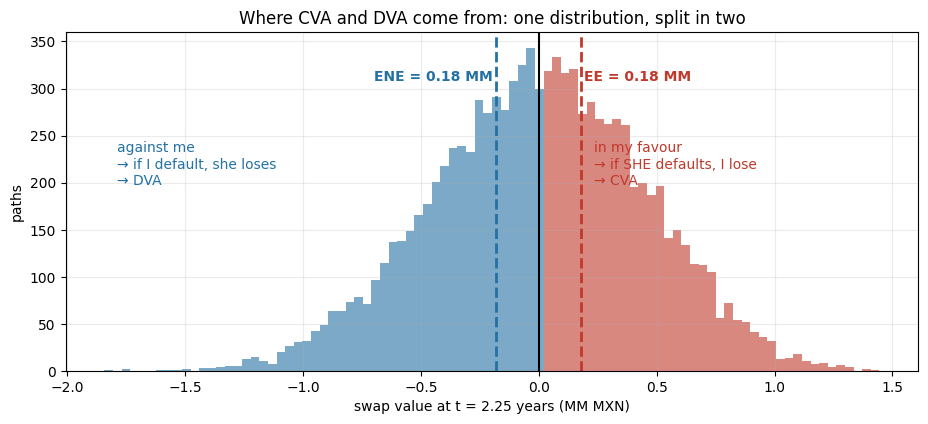

In [4]:
j  = int(EE.argmax()); Vp = V[j]/1e6
fig, ax = plt.subplots(figsize=(11, 4.4))
n, bins, patches = ax.hist(Vp, bins=90, edgecolor='none')
for p, bl in zip(patches, bins[:-1]):
    p.set_facecolor('#c0392b' if bl >= 0 else '#2471a3'); p.set_alpha(.6)
ax.axvline(0, color='k', lw=1.5)
ax.axvline( EE[j]/1e6, color='#c0392b', ls='--', lw=2)
ax.axvline(-ENE[j]/1e6, color='#2471a3', ls='--', lw=2)
ax.text( EE[j]/1e6*1.08, max(n)*.90, f'EE = {EE[j]/1e6:.2f} MM', color='#c0392b', fontweight='bold')
ax.text(-ENE[j]/1e6*1.08, max(n)*.90, f'ENE = {ENE[j]/1e6:.2f} MM', color='#2471a3',
        fontweight='bold', ha='right')
ax.text(.62, .55, 'in my favour\n→ if SHE defaults, I lose\n→ CVA', transform=ax.transAxes,
        color='#c0392b', fontsize=10)
ax.text(.06, .55, 'against me\n→ if I default, she loses\n→ DVA', transform=ax.transAxes,
        color='#2471a3', fontsize=10)
ax.set(xlabel=f'swap value at t = {mon[j]:.2f} years (MM MXN)', ylabel='paths',
       title='Where CVA and DVA come from: one distribution, split in two')
plt.show()

> **One object, two risks.** The swap is at the money and, in this example, the distribution turns
> out roughly centred on zero (being ATM today does not guarantee this in general): it is almost
> equally likely to be worth something in my favour or against me.
>
> - **Red side** (in my favour): the counterparty owes me. If it defaults, **I** lose → this is the
>   **CVA**.
> - **Blue side** (against me): I owe the counterparty. If I default, **it** loses → this is the
>   **DVA**.
>
> **How EE is computed:** keep the positive values, replace the negative ones by zero and average
> **all** scenarios (it is not the mean of the positive values). ENE is the mirror image.
> That is why DVA needs no new model: it is the
> same simulation, the same cube, read from the other chair. And that is why they are nearly equal
> (0.18 MM each): the asymmetry in the final price will come **almost entirely** from the credit spreads.
>
> Both sides are born from a $\max(\cdot,0)$. That non-linearity is the reason a
> netted portfolio's CVA is **not** the sum of the individual CVAs, and much of the thesis's
> technical difficulty comes from it.

### Averaging each side across all dates: the two profiles

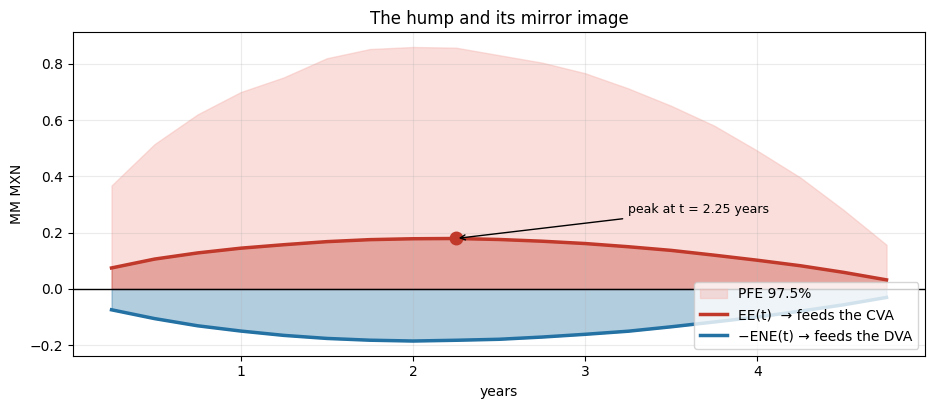

In [5]:
fig, ax = plt.subplots()
ax.fill_between(mon, 0, PFE/1e6, color='#f5b7b1', alpha=.45, label='PFE 97.5%')
ax.fill_between(mon, 0,  EE/1e6, color='#c0392b', alpha=.35)
ax.fill_between(mon, 0, -ENE/1e6, color='#2471a3', alpha=.35)
ax.plot(mon,  EE/1e6, color='#c0392b', lw=2.5, label='EE(t)  → feeds the CVA')
ax.plot(mon, -ENE/1e6, color='#2471a3', lw=2.5, label='−ENE(t) → feeds the DVA')
ax.axhline(0, color='k', lw=1)
ax.plot(mon[j], EE[j]/1e6, 'o', ms=9, color='#c0392b')
ax.annotate(f'peak at t = {mon[j]:.2f} years', xy=(mon[j], EE[j]/1e6), xytext=(mon[j]+1, EE[j]/1e6*1.5),
            arrowprops=dict(arrowstyle='->'), fontsize=9)
ax.set(xlabel='years', ylabel='MM MXN', title='The hump and its mirror image')
ax.legend(loc='lower right'); plt.show()

> **Reading.** The **hump** is the typical exposure profile of a swap: exposure grows because uncertainty
> about rates accumulates, then falls because fewer cash flows remain to be exchanged
> (the amortisation effect). The peak arrives well before maturity: the classic approximation puts it
> near **T/3** (Gregory, 2012); in this demo, with a quarterly grid, it falls in the first half of the life.
>
> For this swap, expected exposure peaks in the early part of its life, not at maturity; that is why
> exposure is reviewed over the whole horizon.
>
> PFE (the pink band) is the 97.5th percentile of exposure: a "reasonable worst case" used to set
> credit lines.

---
## 3 · Pricing it: CVA, DVA and the bilateral adjustment
$$\mathrm{CVA} = (1-R)\sum_i \mathrm{EE}(t_i)\,\Delta\mathrm{PD}(t_i)\,\mathrm{DF}(t_i)
\qquad
\mathrm{DVA} = (1-R)\sum_i \mathrm{ENE}(t_i)\,\Delta\mathrm{PD}^{\text{own}}(t_i)\,\mathrm{DF}(t_i)$$

The only difference between them: **which profile you use and whose credit spread.**

Assumptions: exposure independent of default. The swap is valued in each scenario with its own
rates; expected exposure is discounted with the market curve, which omits the covariance between
discounting and exposure (in the thesis, $+0.25\%$ on the reference swap). The bilateral
adjustment $\mathrm{DVA}-\mathrm{CVA}$ is **simplified**: each term uses one party's marginal
default probabilities and does not model which party defaults first (Gregory, 2012).

In [6]:
def xva_bps(profile, cds_bps):
    lam = cds_bps/1e4/(1 - R)                        # default intensity
    Q   = np.exp(-lam * mon)                         # survival curve
    dPD = -np.diff(np.concatenate([[1.0], Q]))       # marginal probability
    return (1 - R) * np.sum(profile * dPD * DF) / Noc * 1e4

cds_her, cds_mine = 150.0, 80.0                      # change these and re-run!

cva  = xva_bps(EE,  cds_her)
dva  = xva_bps(ENE, cds_mine)
bcva = dva - cva

print(f"  CVA  (her, CDS {cds_her:>5.0f} bps)  = {cva:6.2f} bps = {cva/1e4*Noc:>10,.0f} MXN")
print(f"  DVA  (mine, CDS {cds_mine:>5.0f} bps) = {dva:6.2f} bps = {dva/1e4*Noc:>10,.0f} MXN")
print(f"  {'-'*58}")
print(f"  BCVA = DVA - CVA            = {bcva:+6.2f} bps = {bcva/1e4*Noc:>+10,.0f} MXN")
print(f"\n  -> {'I am the risky one: the adjustment works in my favour.' if bcva > 0 else 'She is the risky one: the adjustment costs me.'}")

  CVA  (her, CDS   150 bps)  =   7.65 bps =      7,650 MXN
  DVA  (mine, CDS    80 bps) =   4.21 bps =      4,214 MXN
  ----------------------------------------------------------
  BCVA = DVA - CVA            =  -3.44 bps =     -3,436 MXN

  -> She is the risky one: the adjustment costs me.


> **Reading.** The profiles were nearly symmetric, but the price is **not**: CVA is almost double
> DVA. The main cause is credit: the counterparty quotes at 150 bps and we quote at 80.
>
> The **BCVA of −3.44 bps** (≈ 3,400 pesos on 10 MM) is the net adjustment. In a real quote, those
> 3.4 bps show up in the price: either absorbed by the margin or passed on to the client.
>
> DVA is **an accounting gain that increases as your own credit deteriorates.** IFRS 13 includes own credit risk when
> measuring liabilities (paragraph 42), but that gain is very hard to monetise. Along the same lines,
> Basel excludes own-credit adjustments from CET1 capital (CAP30.15) and regulatory CVA excludes the
> bank's own default (MAR50.3). The thesis works with unilateral CVA as a **scope decision**, not
> because the standards require it.

### So what? They combine, and who wins depends on who is riskier
With the counterparty's CDS **fixed**, we sweep **ours** from 0 to 400 bps: there is a crossing
point where the bilateral adjustment changes sign.

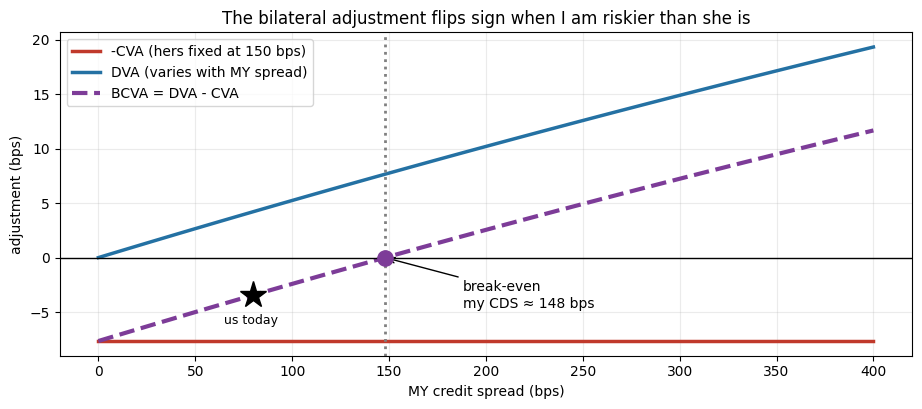

Below 148 bps the net adjustment costs me; above it, it works in my favour.


In [7]:
spreads_mine = np.linspace(0, 400, 60)
cvas = np.full_like(spreads_mine, cva)
dvas = np.array([xva_bps(ENE, s) for s in spreads_mine])
bcvas = dvas - cvas

fig, ax = plt.subplots()
ax.plot(spreads_mine, -cvas, color='#c0392b', lw=2.5, label=f'-CVA (hers fixed at {cds_her:.0f} bps)')
ax.plot(spreads_mine,  dvas, color='#2471a3', lw=2.5, label='DVA (varies with MY spread)')
ax.plot(spreads_mine, bcvas, color='#7d3c98', lw=3, ls='--', label='BCVA = DVA - CVA')
ax.axhline(0, color='k', lw=1)
crossing = np.interp(0, bcvas, spreads_mine)
ax.axvline(crossing, color='gray', ls=':', lw=2)
ax.plot(crossing, 0, 'o', ms=11, color='#7d3c98', zorder=5)
ax.annotate(f'break-even\nmy CDS ≈ {crossing:.0f} bps', xy=(crossing, 0), xytext=(crossing+40, -cva*0.6),
            arrowprops=dict(arrowstyle='->'), fontsize=10)
ax.plot(cds_mine, bcva, '*', ms=20, color='k', zorder=5)
ax.annotate('us today', xy=(cds_mine, bcva), xytext=(cds_mine-15, bcva-cva*0.35), fontsize=9)
ax.set(xlabel='MY credit spread (bps)', ylabel='adjustment (bps)',
       title='The bilateral adjustment flips sign when I am riskier than she is')
ax.legend(loc='upper left'); plt.show()
print(f"Below {crossing:.0f} bps the net adjustment costs me; above it, it works in my favour.")

> **Reading.** Here is the answer to "so how do they combine?".
>
> Holding her CDS **fixed**, we move **mine**. The BCVA (purple line) crosses zero at ≈ **148 bps**,
> very close to her spread (150): **because the two profiles are nearly symmetric, the bilateral
> adjustment nearly vanishes when both parties carry the same credit risk.** Two equally risky
> counterparties with symmetric exposures charge each other almost the same.
>
> - To the left of the crossing (our case, the star): **I am the sounder one**, so the adjustment
>   costs me.
> - To the right: **I am the risky one**, and the adjustment works in my favour.
>
> When two institutions that recognise both adjustments negotiate a swap, this difference is part
> of the price discussion.

---
## 4 · The same swap, six counterparties
Same instrument, notional and date; only the counterparty changes. The spreads are illustrative.

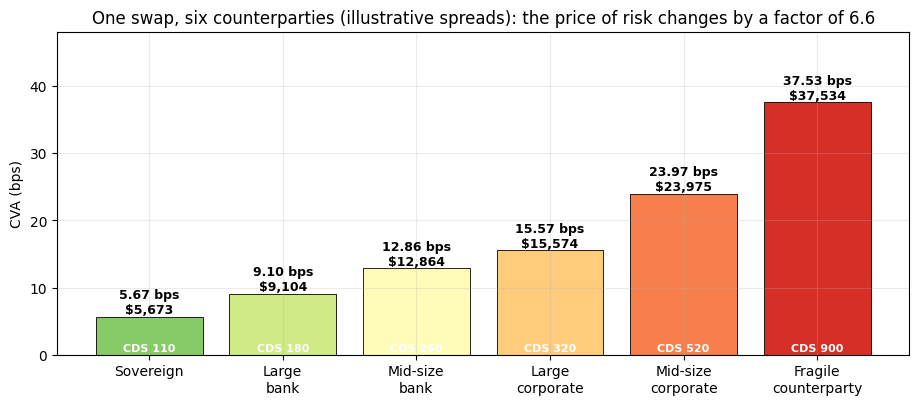

In [8]:
cps = [('Sovereign', 110), ('Large\nbank', 180), ('Mid-size\nbank', 260),
       ('Large\ncorporate', 320), ('Mid-size\ncorporate', 520), ('Fragile\ncounterparty', 900)]
vals = [xva_bps(EE, s) for _, s in cps]

fig, ax = plt.subplots(figsize=(11, 4.2))
bars = ax.bar([c[0] for c in cps], vals, edgecolor='k', lw=.6,
              color=plt.cm.RdYlGn_r(np.linspace(.25, .9, len(cps))))
for bar, v, (_, s) in zip(bars, vals, cps):
    xc = bar.get_x() + bar.get_width()/2
    ax.text(xc, v + .5, f'{v:.2f} bps\n${v/1e4*Noc:,.0f}', ha='center', fontsize=9, fontweight='bold')
    ax.text(xc, .6, f'CDS {s}', ha='center', fontsize=8, color='white', fontweight='bold')
ax.set(ylabel='CVA (bps)', ylim=(0, max(vals)*1.28),
       title='One swap, six counterparties (illustrative spreads): the price of risk changes by a factor of '
             f'{max(vals)/min(vals):.1f}')
plt.show()

> **Reading.** Same instrument, same notional, same date. Only the counterparty changes, and the
> price moves by a factor of **almost 7**, from 5.7 to 37.5 bps.
>
> In pesos: the difference between facing the sovereign and facing the fragile counterparty is
> **32,000 pesos** on a 10-million trade.
>
> Counterparty credit risk has a price, and in this example it is material.

---
## 5 · Why the engine is expensive: the error decays as $1/\sqrt{N}$
To gain one decimal place you have to multiply the number of paths by a hundred. That is what makes it so
costly to reprice a whole book many times a day.

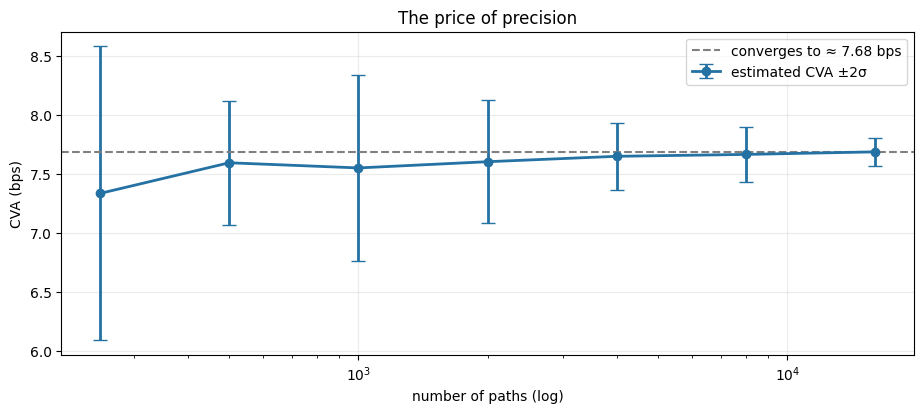

In [9]:
Ns = [250, 500, 1000, 2000, 4000, 8000, 16000]
est, sd = [], []
for N in Ns:
    v = []
    for s in range(5):
        xs, ys = simulate(N=N, seed=100+s)
        Pn_s, an_s = [], []
        for jj, ti in enumerate(mon, start=1):
            rem = pay[pay > ti + 1e-9]
            Pm  = np.stack([P(ti, Tj, xs[:, jj], ys[:, jj]) for Tj in rem], axis=1)
            Pn_s.append(Pm[:, -1]); an_s.append(delta*Pm.sum(axis=1))
        EEs = np.array([np.maximum(Noc*((1-Pn)-K_atm*an), 0).mean() for Pn, an in zip(Pn_s, an_s)])
        v.append(xva_bps(EEs, cds_her))
    est.append(np.mean(v)); sd.append(np.std(v))
est, sd = np.array(est), np.array(sd)

fig, ax = plt.subplots()
ax.errorbar(Ns, est, yerr=2*sd, fmt='o-', capsize=5, lw=2, color='#2471a3', label='estimated CVA ±2σ')
ax.axhline(est[-1], ls='--', color='gray', label=f'converges to ≈ {est[-1]:.2f} bps')
ax.set_xscale('log')
ax.set(xlabel='number of paths (log)', ylabel='CVA (bps)',
       title='The price of precision')
ax.legend(); plt.show()

> **Reading.** With 250 paths the CVA is **imprecise** (±0.6 bps of dispersion on a value of 7.7).
> With 16,000 it is stable, but it costs 64 times more compute.
>
> This is $1/\sqrt{N}$ convergence: **to gain one decimal place you must multiply the work by a
> hundred.**
>
> The error bars **never reach zero**: even the engine's "exact number" is a noisy
> estimator. When we compare ML against Monte Carlo further down, remember that the benchmark is not
> perfect either.

---
## 6 · The surrogate: machine learning that learns from the engine itself
The labels **need no manual labelling** and are cheap: the same cube of paths lets us revalue CVA under different spreads and
fixed rates without simulating again. We train on that.

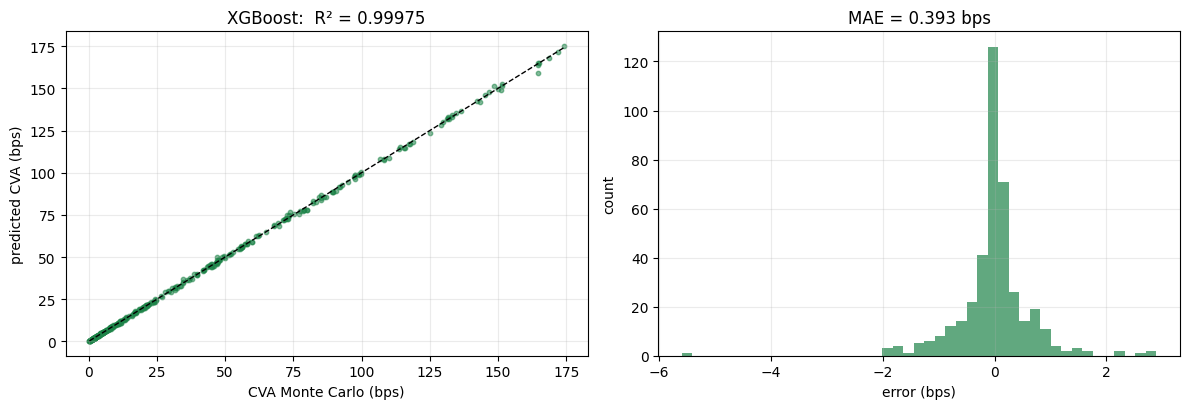

labels: 5.1 s   |   training: 0.23 s


In [10]:
def cva_exact(cds, K):
    EEk = np.array([np.maximum(Noc*((1-Pn) - K*an), 0).mean() for Pn, an in zip(Pn_l, ann_l)])
    return xva_bps(EEk, cds)

rng = np.random.default_rng(7)
Xtr = np.column_stack([rng.uniform(50, 900, 5000), K_atm*rng.uniform(0.6, 1.4, 5000)])
t0 = time.perf_counter(); ytr = np.array([cva_exact(c, k) for c, k in Xtr]); t_lab = time.perf_counter()-t0

try:
    from xgboost import XGBRegressor
    model, name = XGBRegressor(n_estimators=600, max_depth=5, learning_rate=.06), 'XGBoost'
except ImportError:
    from sklearn.ensemble import HistGradientBoostingRegressor
    model, name = (HistGradientBoostingRegressor(max_iter=600, learning_rate=.06,
                        max_leaf_nodes=63), 'HistGradientBoosting')
t0 = time.perf_counter(); model.fit(Xtr, ytr); t_fit = time.perf_counter()-t0

from sklearn.metrics import r2_score
Xte = np.column_stack([rng.uniform(50, 900, 400), K_atm*rng.uniform(0.6, 1.4, 400)])
yte, yp = np.array([cva_exact(c, k) for c, k in Xte]), None
yp = model.predict(Xte)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].scatter(yte, yp, s=10, alpha=.55, color='#1e8449')
lims = [yte.min(), yte.max()]; axes[0].plot(lims, lims, 'k--', lw=1)
axes[0].set(xlabel='CVA Monte Carlo (bps)', ylabel='predicted CVA (bps)',
            title=f'{name}:  R² = {r2_score(yte, yp):.5f}')
axes[1].hist(yp - yte, bins=45, color='#1e8449', alpha=.7)
axes[1].set(xlabel='error (bps)', ylabel='count',
            title=f'MAE = {np.abs(yp-yte).mean():.3f} bps')
plt.tight_layout(); plt.show()
print(f"labels: {t_lab:.1f} s   |   training: {t_fit:.2f} s")

> **Reading.** **R² above 0.999 and a mean error of a few tenths of a basis point** (exact values vary slightly
> across XGBoost versions). The surrogate reproduces the engine very well, and the errors are centred
> on zero (no noticeable systematic bias).
>
> The labels came from the engine
> itself, with no manual labelling: the 5,000 labels cost a few seconds (see above) because the
> cube of paths was already in memory. 
>
> Two observations. First, **the tails** of the histogram: the error is not uniform,
> and it should be measured by region of the domain to learn where the model loses accuracy. Second,
> we train and test **on the same simulation cube**: this measures how well the model learns that
> numerical surface, not its stability under new simulations or new market conditions. Outside the
> training grid, the thesis found that XGBoost's error multiplies (MAE of 4.43 bps versus 0.50) and
> the neural network's does not (0.66 bps). That is why, in production, a *domain of validity* is defined
> for the model.

### What the surrogate unlocks: 14,400 instant valuations
A complete map of CVA as a function of counterparty risk and swap moneyness. With the Monte Carlo
engine, re-simulating for each valuation, it would take orders of magnitude longer.

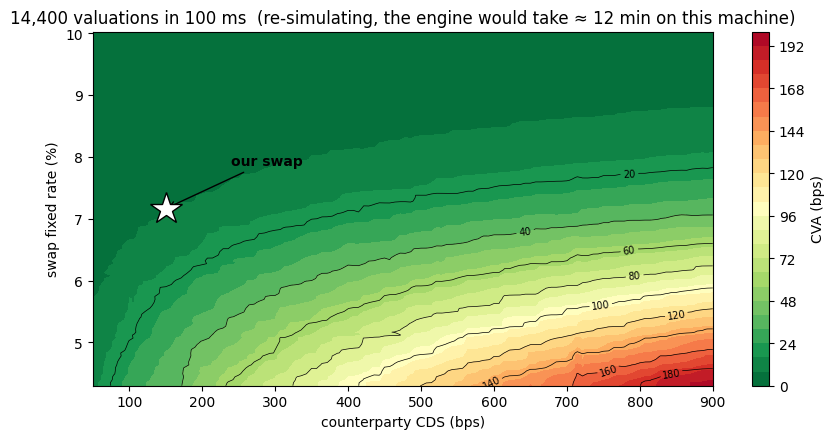

In [11]:
cg = np.linspace(50, 900, 120); kg = K_atm*np.linspace(0.6, 1.4, 120)
CG, KG = np.meshgrid(cg, kg)
t0 = time.perf_counter()
Z = model.predict(np.column_stack([CG.ravel(), KG.ravel()])).reshape(CG.shape)
t_map = time.perf_counter() - t0

fig, ax = plt.subplots(figsize=(10, 4.6))
im = ax.contourf(CG, 100*KG, Z, levels=24, cmap='RdYlGn_r')
cs = ax.contour(CG, 100*KG, Z, levels=9, colors='k', linewidths=.5); ax.clabel(cs, fontsize=7)
ax.plot(cds_her, 100*K_atm, '*', ms=24, color='white', markeredgecolor='k', zorder=5)
ax.annotate('our swap', xy=(cds_her, 100*K_atm), xytext=(cds_her+90, 100*K_atm+0.7),
            arrowprops=dict(arrowstyle='->', color='k'), fontweight='bold')
plt.colorbar(im, label='CVA (bps)')
ax.set(xlabel='counterparty CDS (bps)', ylabel='swap fixed rate (%)',
       title=f'{CG.size:,} valuations in {t_map*1000:.0f} ms  '
             f'(re-simulating, the engine would take ≈ {CG.size*(t_sim + t_val)/60:.0f} min on this machine)')
ax.grid(False); plt.show()

> **Reading.** 14,400 valuations in a fraction of a second. With the engine, re-simulating each time, it would
> take **minutes** (the title gives the estimate on this machine). With the surrogate, exploring the whole scenario space becomes practical.
>
> Reading the map: CVA grows to the right (worse credit) and downwards (swap further in the money).
> The contour lines bend because **the two effects multiply**: the impact of credit is larger
> when exposure is already high.
>
> The contour lines are staircases, not smooth curves: this comes from the tree's discrete splits. It predicts the level with very high accuracy,
> but its derivative is zero inside each leaf. This is consistent with the thesis finding: XGBoost fails on *sensitivities*
> (33.2% error in CS01 and 545.7% in the PC2 PV01, with the wrong sign), so a local Ridge regression is
> used for them, valid only within its training domain, and boosting is reserved for levels. The appropriate model depends on the use.

---
## 7 · The race

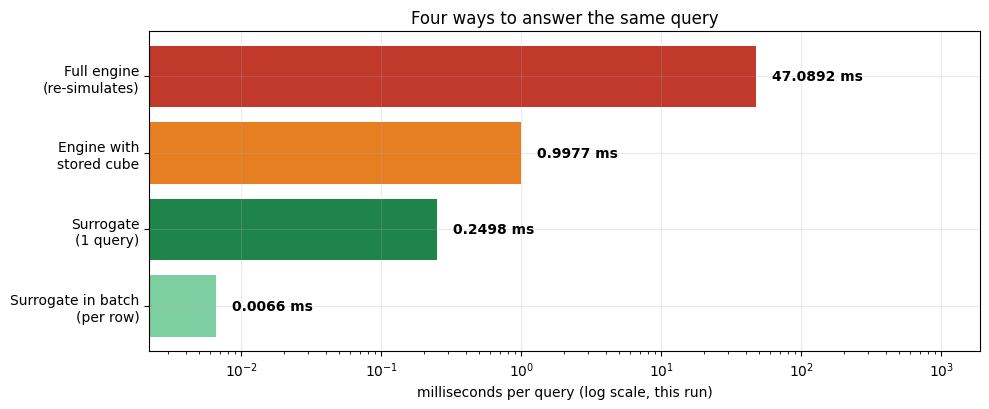

Full engine ÷ surrogate (1 query): 188 times
Engine with cube ÷ surrogate (1 query): 4.0 times (above 1: the surrogate wins; below 1: the engine wins)
Break-even against the full engine: ≈ 115 queries (cost of labelling and training ÷ saving per query)

[Thesis: in its configuration (five variables, several tenors and curve levels), the surrogates
 are 10^3 to 10^5 times faster than the full engine, on average per query when pricing
 in batch. These are wall-clock times on one machine; they vary between runs and exclude training.]


In [12]:
def timed(f, n=200):
    """Average time per call (s): one warm-up call, then n repetitions."""
    f(); t0 = time.perf_counter()
    for _ in range(n): f()
    return (time.perf_counter() - t0) / n

# (1) Full engine: re-simulate, revalue and aggregate, for a single query.
t0 = time.perf_counter()
xr, yr = simulate(N=10_000)
Pn_r, an_r = [], []
for jj, ti in enumerate(mon, start=1):
    rem = pay[pay > ti + 1e-9]
    Pm  = np.stack([P(ti, Tj, xr[:, jj], yr[:, jj]) for Tj in rem], axis=1)
    Pn_r.append(Pm[:, -1]); an_r.append(delta*Pm.sum(axis=1))
EEr = np.array([np.maximum(Noc*((1-Pn)-K_atm*an), 0).mean() for Pn, an in zip(Pn_r, an_r)])
_ = xva_bps(EEr, cds_her)
t_mc = time.perf_counter() - t0

# (2) Engine with the stored cube: only the spread or the fixed rate changes, no new simulation.
t_cubo = timed(lambda: cva_exact(cds_her, K_atm))

# (3) Surrogate, one query at a time: the latency seen by someone asking one thing at a time.
x1 = np.array([[cds_her, K_atm]])
t_ml1 = timed(lambda: model.predict(x1))

# (4) Surrogate in batch: average cost per row when pricing 200,000 queries together.
Xq = np.column_stack([np.full(200_000, cds_her), np.full(200_000, K_atm)])
t0 = time.perf_counter(); model.predict(Xq); t_lote = (time.perf_counter() - t0)/200_000

labels = ['Full engine\n(re-simulates)', 'Engine with\nstored cube',
          'Surrogate\n(1 query)', 'Surrogate in batch\n(per row)']
ms = np.array([t_mc, t_cubo, t_ml1, t_lote])*1000
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.barh(labels, ms, color=['#c0392b', '#e67e22', '#1e8449', '#7dcea0'])
ax.set_xscale('log'); ax.invert_yaxis(); ax.set_xlim(ms.min()/3, ms.max()*40)
for i, v in enumerate(ms):
    ax.text(v*1.3, i, f'{v:,.4f} ms', va='center', fontweight='bold')
ax.set(xlabel='milliseconds per query (log scale, this run)',
       title='Four ways to answer the same query')
plt.tight_layout(); plt.show()

print(f"Full engine ÷ surrogate (1 query): {t_mc/t_ml1:,.0f} times")
print(f"Engine with cube ÷ surrogate (1 query): {t_cubo/t_ml1:,.1f} times "
      "(above 1: the surrogate wins; below 1: the engine wins)")
print(f"Break-even against the full engine: ≈ {(t_lab + t_fit)/(t_mc - t_ml1):,.0f} queries "
      "(cost of labelling and training ÷ saving per query)")
print("\n[Thesis: in its configuration (five variables, several tenors and curve levels), the surrogates\n"
      " are 10^3 to 10^5 times faster than the full engine, on average per query when pricing\n"
      " in batch. These are wall-clock times on one machine; they vary between runs and exclude training.]")


> **Reading.** The comparison covers four cases:
>
> - **Full engine:** re-simulates and revalues. This is the cost when a query forces a new simulation.
> - **Engine with stored cube:** in this demo, the spread and the fixed rate change without a new
>   simulation, so the engine is already fast. Against it, the surrogate's advantage is small or may
>   not exist, depending on the machine.
> - **Surrogate, one query:** the latency seen by someone asking one thing at a time; it includes each
>   call's fixed overhead.
> - **Surrogate in batch:** the average cost per row when pricing many queries together. It is the
>   lowest figure, but it is not the latency of an individual query.
>
> In short: this surrogate learns a two-variable surface (spread and fixed rate), which the engine
> also resolves with the stored cube. The thesis surrogates also take tenor and curve level as
> inputs; their advantage is measured against the best reusable engine in each case. No bar includes generating labels or training; the cell computes how many queries it
> takes to recover that cost against the full engine. For an isolated query, Monte Carlo is still
> cheaper end to end.

---
## 8 · Real-time pre-deal quoting
A client asks for a quote. The desk computes the CVA of **several alternatives** while handling the
request.

In [13]:
scenarios = [('Client A: large bank',              180, K_atm),
             ('Client B: mid-size corp.',        520, K_atm),
             ('Client B, swap ~20 bps ITM',      520, K_atm*0.97),
             ('Client B, swap ~20 bps OTM',      520, K_atm*1.03),
             ('Client C: fragile counterparty', 900, K_atm)]

t0 = time.perf_counter()
pred = [model.predict(np.array([[c, k]]))[0] for _, c, k in scenarios]
t_todo = time.perf_counter() - t0
t0 = time.perf_counter()
exact = [cva_exact(c, k) for _, c, k in scenarios]         # cross-check against the engine (stored cube)
t_ver = time.perf_counter() - t0

print(f"{'Scenario':<32}{'CDS':>5}{'K':>8}{'ML':>9}{'engine':>9}{'diff':>7}{'MXN':>12}")
print('─'*82)
for (n, c, k), p, e in zip(scenarios, pred, exact):
    print(f"{n:<32}{c:>5.0f}{k:>8.2%}{p:>8.2f}{e:>9.2f}{p-e:>+7.2f}{p/1e4*Noc:>12,.0f}")
print('─'*82)
print(f"The {len(scenarios)} quotes: surrogate {t_todo*1000:.1f} ms; engine with stored cube "
      f"{t_ver*1000:.1f} ms; engine re-simulating ≈ {len(scenarios)*t_mc:.2f} s.")
print("\nCross-check against the engine: five queries cannot tell where the model fails;\n"
      "that is measured by region of the domain and outside the training grid.")
print("In production, that reconciliation is an indispensable part of model governance.")

Scenario                          CDS       K       ML   engine   diff         MXN
──────────────────────────────────────────────────────────────────────────────────
Client A: large bank              180   7.16%    9.00     9.10  -0.10       9,000
Client B: mid-size corp.          520   7.16%   23.92    23.97  -0.05      23,921
Client B, swap ~20 bps ITM        520   6.95%   27.76    28.98  -1.22      27,756
Client B, swap ~20 bps OTM        520   7.38%   20.81    19.72  +1.09      20,812
Client C: fragile counterparty    900   7.16%   36.69    37.53  -0.85      36,689
──────────────────────────────────────────────────────────────────────────────────
The 5 quotes: surrogate 2.2 ms; engine with stored cube 6.7 ms; engine re-simulating ≈ 0.24 s.

Cross-check against the engine: five queries cannot tell where the model fails;
that is measured by region of the domain and outside the training grid.
In production, that reconciliation is an indispensable part of model governance.


> **Reading.** Five alternatives quoted in milliseconds.
>
> Moneyness effect: according to the engine, the same client B pays **about 29 bps** if the
> swap is in the money and **about 20 bps** if it is out of the money. CVA depends not only on *who*
> the counterparty is, but on *how much* they will owe you.
>
> In the "diff" column, the error ranges from hundredths to about 1 bp. Five
> queries are not enough to conclude where the model loses accuracy: that requires measuring the
> error by region of the domain, and outside the training grid, which is where the thesis found the
> large differences. That is why periodic reconciliation against the engine is an indispensable part
> of model governance.
>
> In this demo, the engine with the stored cube also answers these queries in
> milliseconds, because only the spread and the fixed rate change. This surrogate only takes the spread and the
> fixed rate; the thesis surrogates, with tenor and curve level as inputs, are the ones that avoid a
> new simulation.

---
## What is missing for production

Full Valmer curve and bootstrapping of real CDS · calibration to the swaption surface · portfolio
with netting by counterparty · incremental pre-deal CVA · sensitivities (PV01, CS01) for hedging
· Banxico's monthly XVA report · trade-level attribution · validation, domain of validity and model governance.

*G2++ parameters: calibrated in the thesis «Comparación de métodos numéricos para el cálculo de CVA en
swaps de tasas de interés» to ATM swaptions (Bloomberg SWPM, 24-Mar-2026). Rate level and spreads:
illustrative demo assumptions. Recovery: emerging-market CDS convention (Iwashita, 2013).*